In [1]:
# ! pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu122

In [2]:
# ! pip install transformers datasets torch

In [3]:
# ! pip install scikit-learn
# ! pip install scikit-learn numpy pandas matplotlib

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

/home/ebratul/Documents/code/mubarak/torch_gpu_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
emotions = load_dataset("emotion")
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
emotions["train"][:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [7]:
import pandas as pd

df_train = pd.DataFrame(emotions["train"])

df_train.head(5)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [8]:
df_train['label'].unique()


array([0, 3, 2, 5, 4, 1])

In [9]:
import pandas as pd

df_test = pd.DataFrame(emotions["test"])

df_test.head(3)

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0


In [10]:
for emotion in df_train["label"].unique():
    example = df_train[df_train["label"] == emotion]["text"].iloc[0]
    print(f"Class: {emotion} → Example: {example}")

Class: 0 → Example: i didnt feel humiliated
Class: 3 → Example: im grabbing a minute to post i feel greedy wrong
Class: 2 → Example: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Class: 5 → Example: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
Class: 4 → Example: i feel as confused about life as a teenager or as jaded as a year old man
Class: 1 → Example: i have been with petronas for years i feel that petronas has performed well and made a huge profit


In [12]:
# 1. Load dataset
dataset = load_dataset("emotion")
train_data = dataset["train"]
test_data = dataset["test"]

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [32]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import torch

# Train/test split
x_train_text = df_train['text']
x_test_text = df_test['text']
y_train = df_train['label']
y_test = df_test['label']

# Convert text → numeric features (Bag-of-Words)
vectorizer = CountVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(x_train_text).toarray()
X_test = vectorizer.transform(x_test_text).toarray()

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)


In [33]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Train/Test dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [34]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [51]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [36]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=float(lr), weight_decay=1e-5)
    early_stopping = EarlyStopping(patience=patience)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss /= len(test_loader)
        val_acc = val_correct / val_total

        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return train_losses, val_losses, train_accs, val_accs

In [37]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6):
        super(NeuralNet, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),   # dropout rate বাড়ানো হয়েছে

            nn.Linear(64, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),

            nn.Linear(64, 32), # hidden dimension কমানো হয়েছে (16 → 32)
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [38]:
import torch
import torch.nn as nn

class LSTMFeatures(nn.Module):
    def __init__(self, input_dim=5000, hidden_dim=64, num_classes=6):
        super(LSTMFeatures, self).__init__()
        # hidden_dim কমানো হয়েছে (128 → 64) যাতে মডেল কম complex হয়
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, dropout=0.5)

        # FC layer with stronger dropout
        self.fc = nn.Sequential(
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.5),   # dropout rate বাড়ানো হয়েছে
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [batch, seq_len=1, input_dim]
        _, (h_n, _) = self.lstm(x)
        h_n = h_n.squeeze(0)
        return self.fc(h_n)


In [39]:
import torch
import torch.nn as nn

class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6, hidden_dim=128, nhead=4, num_layers=2):
        super(TransformerClassifier, self).__init__()
        
        # Input projection
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        
        # Transformer encoder with dropout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, 
            nhead=nhead, 
            dropout=0.5,          # dropout rate বাড়ানো হয়েছে
            activation='relu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Regularization layers
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(0.5)
        
        # Output
        self.fc_out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Project input features
        x = self.fc_in(x).unsqueeze(1)  # [batch, seq_len=1, hidden_dim]
        
        # Transformer encoder
        x = self.transformer(x)
        
        # Pooling + regularization
        x = x.mean(dim=1)               # mean pooling
        x = self.layernorm(x)
        x = self.dropout(x)
        
        return self.fc_out(x)


In [40]:
class CNNClassifier(nn.Module):
    def __init__(self, input_dim=5000, num_classes=6):
        super(CNNClassifier, self).__init__()
        
        # Conv block 1
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool1d(4)   # বেশি pooling → dimension ছোট হবে
        self.dropout1 = nn.Dropout(0.5)

        # Conv block 2
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)
        self.dropout2 = nn.Dropout(0.5)

        # Global average pooling → huge flatten এড়ানো
        self.gap = nn.AdaptiveAvgPool1d(1)

        # Fully connected
        self.fc1 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.5)
        self.fc_out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)              # [batch, 1, input_dim]
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        # Global average pooling → [batch, 64, 1]
        x = self.gap(x)
        x = x.squeeze(-1)               # [batch, 64]

        x = self.fc1(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)

        return self.fc_out(x)


In [42]:
print("start NN training....")
model_nn = NeuralNet(input_dim=X_train.shape[1], num_classes=6)
train_losses, val_losses, train_accs, val_accs = train_model(model_nn, train_loader, test_loader)


start NN training....
Epoch 1/50 | Train Loss: 1.6102 | Train Acc: 0.3754 | Val Loss: 1.1147 | Val Acc: 0.5960
Epoch 2/50 | Train Loss: 1.0932 | Train Acc: 0.6017 | Val Loss: 0.7985 | Val Acc: 0.6925
Epoch 3/50 | Train Loss: 0.8078 | Train Acc: 0.7127 | Val Loss: 0.5339 | Val Acc: 0.8275
Epoch 4/50 | Train Loss: 0.6157 | Train Acc: 0.7961 | Val Loss: 0.4243 | Val Acc: 0.8545
Epoch 5/50 | Train Loss: 0.4820 | Train Acc: 0.8488 | Val Loss: 0.3948 | Val Acc: 0.8720
Epoch 6/50 | Train Loss: 0.4218 | Train Acc: 0.8676 | Val Loss: 0.3833 | Val Acc: 0.8720
Epoch 7/50 | Train Loss: 0.3632 | Train Acc: 0.8884 | Val Loss: 0.3898 | Val Acc: 0.8685
Epoch 8/50 | Train Loss: 0.3250 | Train Acc: 0.9004 | Val Loss: 0.3813 | Val Acc: 0.8720
Epoch 9/50 | Train Loss: 0.2937 | Train Acc: 0.9139 | Val Loss: 0.3989 | Val Acc: 0.8695
Epoch 10/50 | Train Loss: 0.2815 | Train Acc: 0.9147 | Val Loss: 0.3914 | Val Acc: 0.8775
Epoch 11/50 | Train Loss: 0.2693 | Train Acc: 0.9202 | Val Loss: 0.4040 | Val Acc: 0.87

In [46]:
# LSTM
print("start LSTM traning....")


# Model initialize
model_lstm = LSTMFeatures(input_dim=X_train.shape[1], num_classes=6)


# Train with DataLoader + EarlyStopping
train_losses, val_losses, train_accs, val_accs = train_model(
    model_lstm, train_loader, test_loader, epochs=50, lr=0.001, patience=5
)

start LSTM traning....
Epoch 1/50 | Train Loss: 1.2908 | Train Acc: 0.5191 | Val Loss: 0.5919 | Val Acc: 0.8405
Epoch 2/50 | Train Loss: 0.4219 | Train Acc: 0.8668 | Val Loss: 0.3181 | Val Acc: 0.8915
Epoch 3/50 | Train Loss: 0.2410 | Train Acc: 0.9213 | Val Loss: 0.3097 | Val Acc: 0.8865
Epoch 4/50 | Train Loss: 0.1768 | Train Acc: 0.9416 | Val Loss: 0.3282 | Val Acc: 0.8835
Epoch 5/50 | Train Loss: 0.1431 | Train Acc: 0.9531 | Val Loss: 0.3371 | Val Acc: 0.8790
Epoch 6/50 | Train Loss: 0.1270 | Train Acc: 0.9586 | Val Loss: 0.3537 | Val Acc: 0.8805
Epoch 7/50 | Train Loss: 0.1151 | Train Acc: 0.9606 | Val Loss: 0.3857 | Val Acc: 0.8775
Epoch 8/50 | Train Loss: 0.1002 | Train Acc: 0.9667 | Val Loss: 0.3744 | Val Acc: 0.8860
Early stopping triggered!


In [50]:
# Transformer

print("start Transformer traning....")


# Transformer Model initialize
model_trans = TransformerClassifier(input_dim=X_train.shape[1], num_classes=6)

# Train with DataLoader + EarlyStopping
train_losses, val_losses, train_accs, val_accs = train_model(
    model_trans, train_loader, test_loader, epochs=50, lr=0.001, patience=5
)


start Transformer traning....


Epoch 1/50 | Train Loss: 0.8777 | Train Acc: 0.6941 | Val Loss: 0.5326 | Val Acc: 0.8355
Epoch 2/50 | Train Loss: 0.3493 | Train Acc: 0.8926 | Val Loss: 0.5622 | Val Acc: 0.8415
Epoch 3/50 | Train Loss: 0.2521 | Train Acc: 0.9224 | Val Loss: 0.6009 | Val Acc: 0.8455
Epoch 4/50 | Train Loss: 0.2063 | Train Acc: 0.9353 | Val Loss: 0.6323 | Val Acc: 0.8410
Epoch 5/50 | Train Loss: 0.1711 | Train Acc: 0.9472 | Val Loss: 0.6382 | Val Acc: 0.8565
Epoch 6/50 | Train Loss: 0.1473 | Train Acc: 0.9537 | Val Loss: 0.7713 | Val Acc: 0.8545
Early stopping triggered!


In [48]:

# CNN

# CNN Model initialize
model_cnn = CNNClassifier(input_dim=X_train.shape[1], num_classes=6)

# Train with DataLoader + EarlyStopping
train_losses, val_losses, train_accs, val_accs = train_model(
    model_cnn, train_loader, test_loader, epochs=50, lr=0.001, patience=5
)

Epoch 1/50 | Train Loss: 1.6620 | Train Acc: 0.3115 | Val Loss: 1.5804 | Val Acc: 0.3415
Epoch 2/50 | Train Loss: 1.6048 | Train Acc: 0.3329 | Val Loss: 1.5809 | Val Acc: 0.3475
Epoch 3/50 | Train Loss: 1.5910 | Train Acc: 0.3382 | Val Loss: 1.5735 | Val Acc: 0.3475
Epoch 4/50 | Train Loss: 1.5853 | Train Acc: 0.3367 | Val Loss: 1.5749 | Val Acc: 0.3460
Epoch 5/50 | Train Loss: 1.5803 | Train Acc: 0.3395 | Val Loss: 1.5665 | Val Acc: 0.3235
Epoch 6/50 | Train Loss: 1.5796 | Train Acc: 0.3391 | Val Loss: 1.5665 | Val Acc: 0.3420
Epoch 7/50 | Train Loss: 1.5782 | Train Acc: 0.3384 | Val Loss: 1.5648 | Val Acc: 0.3495
Epoch 8/50 | Train Loss: 1.5759 | Train Acc: 0.3390 | Val Loss: 1.5635 | Val Acc: 0.3475
Epoch 9/50 | Train Loss: 1.5764 | Train Acc: 0.3408 | Val Loss: 1.5628 | Val Acc: 0.3420
Epoch 10/50 | Train Loss: 1.5754 | Train Acc: 0.3397 | Val Loss: 1.5629 | Val Acc: 0.3445
Epoch 11/50 | Train Loss: 1.5753 | Train Acc: 0.3387 | Val Loss: 1.5624 | Val Acc: 0.3370
Epoch 12/50 | Train

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # Accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Precision, Recall, F1 (macro average for multi-class)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1


In [58]:
# ধরো তুমি CNN train করেছো
acc, prec, rec, f1 = evaluate_metrics(model_cnn, test_loader)


# # অথবা LSTM/Transformer/NN এর জন্যও একইভাবে
# acc, prec, rec, f1 = evaluate_metrics(model_lstm, test_loader)


Accuracy:  0.3490
Precision: 0.1138
Recall:    0.1717
F1-Score:  0.1190


/home/ebratul/Documents/code/mubarak/torch_gpu_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
import matplotlib.pyplot as plt

def plot_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses)+1)

    plt.figure(figsize=(12,5))

    # Loss curves
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    # Accuracy curves
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, 'b-', label='Train Acc')
    plt.plot(epochs, val_accs, 'r-', label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    plt.show()


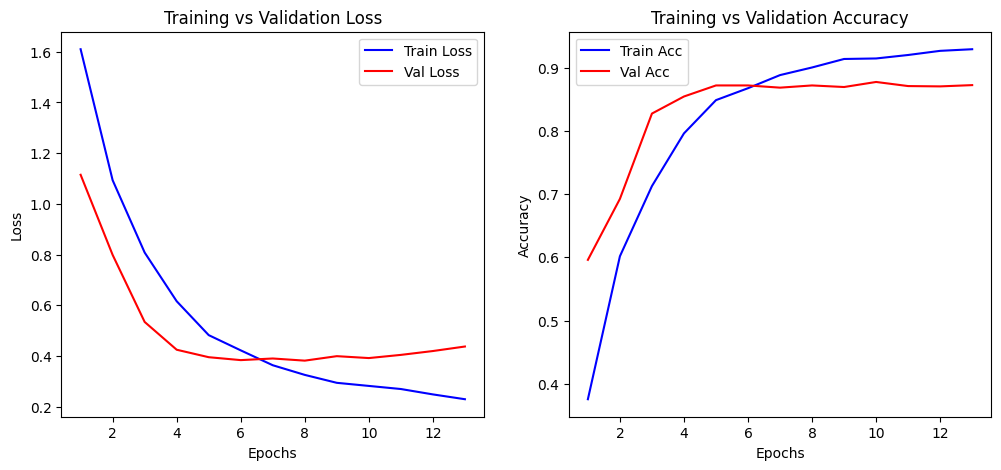

In [44]:
plot_curves(train_losses, val_losses, train_accs, val_accs)